In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Newtonian Cooling
In this noteboook I would like to get introductory practice using and plotting using the scipy solve_ivp and other functionality.
We will do so initially by solving forward Newton's law of cooling. A single first order ODE.

$$\dot{T} = -k(T-T_s)$$

Where $k$ is a constant of proportionality and $T_s$ is the equilibrium temperature.
I will use $k = 0.3$ and $T_s = 22$. We will let $T(0) = 90$.

Success status: True
Times Array shape: (100,)
Values Array shape: (1, 100)


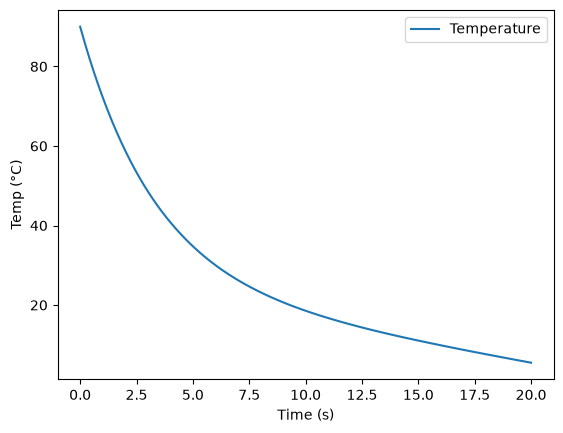

In [3]:
# We define the system function
def dynamic_cooling_system(t,T):
    T_env = 22-1.0*t
    return -0.3*(T - T_env)

#Set the span and initial conditions
t_span = (0,20)
T0 = [90]

#Run the Solver
#t_eval forces the solver to save results  at these specific timestamps
t_eval= np.linspace(0,20,100)
sol = solve_ivp(dynamic_cooling_system,t_span,T0,t_eval = t_eval)


# 4. Access the results
print("Success status:", sol.success)
print("Times Array shape:", sol.t.shape)
print("Values Array shape:", sol.y.shape)

# Plotting the result
plt.plot(sol.t, sol.y[0], label="Temperature")
plt.xlabel("Time (s)")
plt.ylabel("Temp (°C)")
plt.legend()
plt.show()

## Rockets
I will now try this out for a higher order ODE's.
I'll try this out first on the rocket equation.

$$m(t)\dot{v} = T-m(t)g$$
where $T$ is thrust and is a constant but $m(t)$ is its own equation. We could say the rocket burns fuel at a constant rate.
$$m(t) = m_0 - rt$$
For find velocity we solve the ODE
$$\dot{v} = \frac{T}{m(t)} - g$$
Let set $T = 100$, $m_0 = 10$, $r=1$, and of course $g = 10$

Success status: True
Times Array shape: (100,)
Values Array shape: (2, 100)


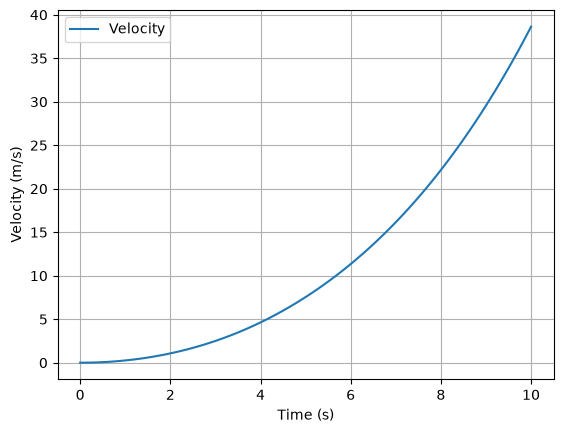

In [4]:
#setup functions and constants

T = 100
m0 = 10
v0 = 0.0
mdot = 0.5
g = 10


def rocket(t,y):
    v,m = y
    dvdt = T/m - g
    dmdt = -mdot
    dydt = [dvdt,dmdt]

    return dydt

# Set span and initial conditions
t_span = (0,10)
y0 = [v0,m0]

#Run the solver
t_eval = np.linspace(0,10,100)
sol = solve_ivp(rocket,t_span, y0,t_eval = t_eval)

# 4. Access the results
print("Success status:", sol.success)
print("Times Array shape:", sol.t.shape)
print("Values Array shape:", sol.y.shape)

# Plotting the result
plt.plot(sol.t, sol.y[0], label="Velocity")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.grid()
plt.legend()
plt.show()

## Predator-Prey

We now consider the Lotka-Volterra predator - prey model. Which constitutes a set of coupled ODE's.

$$\dot{P} = \alpha P - \beta PQ$$
$$ \dot{Q} = \delta PQ - \gamma Q$$

With $P$ representing the population of rabbits and $Q$ representing the population of wolves. 

Where $\alpha$, $\beta$, $\delta$, $\gamma$ represent the natural birth rate of prey, the effeciacy with which wolves consume rabbits, how effectively eating rabbites translates to population growth, and the natural death rate of wolves, respectively.

Success status: True
Times Array shape: (5000,)
Values Array shape: (2, 5000)


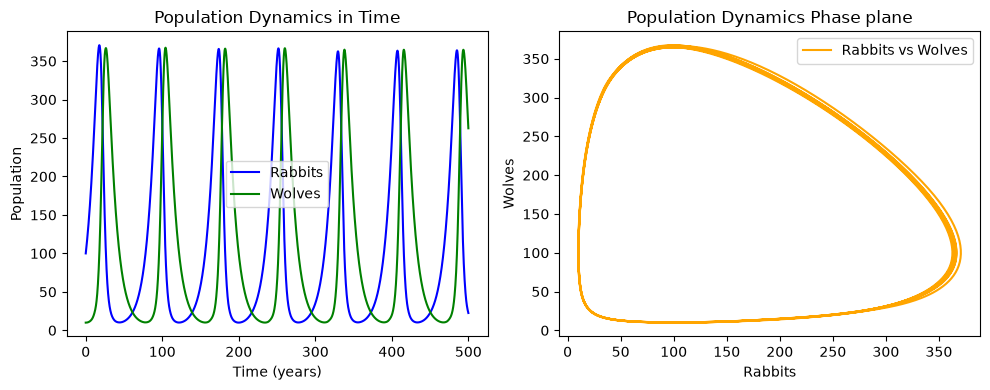

In [10]:
P0 = 100
Q0 = 10
alpha = 0.1
beta = 0.001
gamma = 0.1
delta = 0.001

def PredPrey(t,y):
    P,Q = y
    dPdt = alpha * P - beta * P * Q
    dQdt = delta * P * Q - gamma * Q
    dydt = [dPdt,dQdt]
    return dydt

t_span = [0,500]
y0 = [P0,Q0]

t_eval = np.linspace(0,500,5000)
sol = solve_ivp(PredPrey,t_span,y0,t_eval = t_eval)

print("Success status:", sol.success)
print("Times Array shape:", sol.t.shape)
print("Values Array shape:", sol.y.shape)

# Plotting the result
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot the first graph (Left)
ax1.plot(sol.t, sol.y[0], color='blue', label = "Rabbits")
ax1.plot(sol.t,sol.y[1], color = "green", label = "Wolves")
ax1.set_title('Population Dynamics in Time')
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Population')
ax1.legend()

# Plot the second graph (Right)
ax2.plot(sol.y[0], sol.y[1], color='orange', label = "Rabbits vs Wolves")
ax2.set_title('Population Dynamics Phase plane')
ax2.set_xlabel('Rabbits')
ax2.set_ylabel('Wolves')
ax2.legend()

# Automatically adjust spacing between graphs to avoid overlap
plt.tight_layout()

# Display the graphs
plt.show()

## Second Order Financial Model

Here we consider the price of an asset relative to some equilibrium price. 

It is defined as 

$$\ddot{P} + \alpha \dot{P} + \beta(P - P_{eq}) = 0$$

We decompose this into a sytem of lower order equations.

$$\dot{V} = -\alpha V - \beta(P - P_{eq})$$
$$\dot{P} = V$$

We easily adopt our above code for this process.

Success status: True
Times Array shape: (10000,)
Values Array shape: (2, 10000)


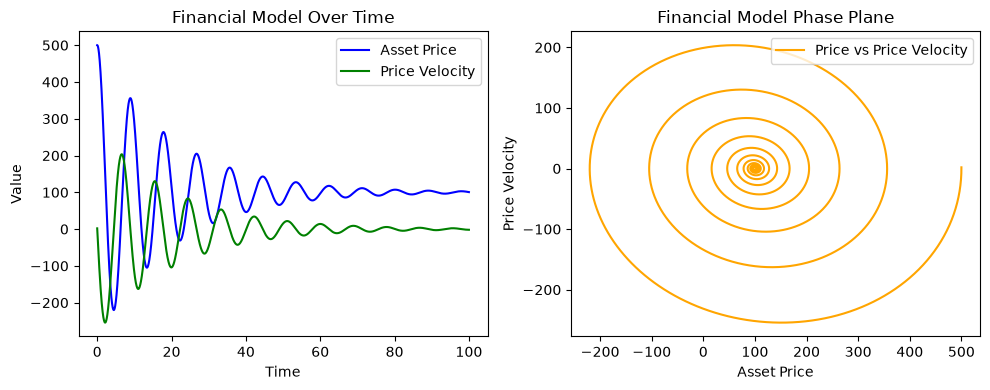

In [17]:
peq = 100
p0 = 500
v0 = 2
alpha = 0.1
beta = 0.5


def model(t,y):
    p,v = y
    dpdt = v
    dvdt = -alpha * v - beta * (p - peq)
    dydt = [dpdt,dvdt]
    return dydt

# Create t_span and y0
t_span = [0,100]
y0 = [p0,v0]

t_eval = np.linspace(0,100,10000)
sol = solve_ivp(model,t_span, y0, t_eval = t_eval)

print("Success status:", sol.success)
print("Times Array shape:", sol.t.shape)
print("Values Array shape:", sol.y.shape)

# Plotting the result
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot the first graph (Left)
ax1.plot(sol.t, sol.y[0], color='blue', label="Asset Price")
ax1.plot(sol.t, sol.y[1], color='green', label="Price Velocity")
ax1.set_title('Financial Model Over Time')
ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.legend()

# Plot the second graph (Right)
ax2.plot(sol.y[0], sol.y[1], color='orange',
         label="Price vs Price Velocity")
ax2.set_title('Financial Model Phase Plane')
ax2.set_xlabel('Asset Price')
ax2.set_ylabel('Price Velocity')
ax2.legend()

# Automatically adjust spacing between graphs
plt.tight_layout()

# Display the graphs
plt.show()

